<a href="https://colab.research.google.com/github/SANJANA7-hrud/Computer-Vision/blob/main/FaceDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
!pip install opencv-python matplotlib --quiet

In [7]:
import cv2
from matplotlib import pyplot as plt
from google.colab import files

#cv2 -> all computer vision function
#matplotlit

In [15]:
image_file= '/content/स्क्रीनशॉट 2026-03-13 104654.png'
image = cv2.imread(image_file)


#files.upload() opens a files picture to select an image from you pc
#uplaoded.keys gives the file name you just uploaded

In [16]:
image=cv2.imread(image_file)
image_rgb = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

 #convert for proper display

#cv2.imread()-> reads the image as an array (openv works with array)
#opencv reads BGR format by default . But matplotlib uses RBG format ,so we convert it

In [26]:
!wget -O haar_face.xml https://github.com/opencv/opencv/raw/master/data/haarcascades/haarcascade_frontalface_default.xml
!wget -O haar_eye.xml https://github.com/opencv/opencv/raw/master/data/haarcascades/haarcascade_eye.xml

face_cascade=cv2.CascadeClassifier('haar_face.xml')
eye_cascade=cv2.CascadeClassifier('haar_eye.xml')

#wget-> command-line tool to download files from the internet
#-0 haar_face.xml -> save the downloaded files locally with the name haar_face.xml
#The URL  -> point to opencv's pre-trained haar cascade file for frontal face detection
#Haar cascade -> pre-trained model to detect faces
#CascadeClassifier() -> load the model so we can use it

--2026-03-13 06:41:36--  https://github.com/opencv/opencv/raw/master/data/haarcascades/haarcascade_frontalface_default.xml
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml [following]
--2026-03-13 06:41:37--  https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 930127 (908K) [text/plain]
Saving to: ‘haar_face.xml’

haar_face.xml       100%[===================>] 908.33K  5.34MB/s    in 0.2s    

2026-03-13 06:41:37 (5.3

In [19]:
gray= cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)

#Face detection works faster and better on graysacle images

In [21]:
faces= face_cascade.detectMultiScale(gray,scaleFactor=1.1,minNeighbors=5)

In [27]:
image_with_detections = image_rgb.copy()

for (x,y,w,h) in faces:
  cv2.rectangle(image_with_detections,(x,y),(x+w,y+h),(255,0,0),2) # Draw face rectangle (Blue)

  roi_gray = gray[y:y+h, x:x+w]
  roi_color = image_with_detections[y:y+h, x:x+w]

  eyes = eye_cascade.detectMultiScale(roi_gray)
  for (ex,ey,ew,eh) in eyes:
    cv2.rectangle(roi_color,(ex,ey),(ex+ew,ey+eh),(0,255,0),2) # Draw eye rectangle (Green)

  #(x,y,w,h) -> coordinates of detected face
  #cv2.rectangle() -> draws a rectangle on the image
  #(255,0,0) -> blue rectangle for face in RGB
  #(0,255,0) -> green rectangle for eye in RGB
  #2 -> thickness of the rectangle

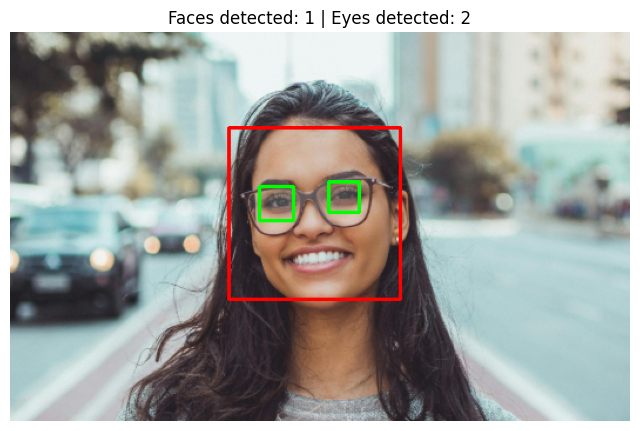

In [28]:
plt.figure(figsize=(8,6))
plt.imshow(image_with_detections)
plt.title(f'Faces detected: {len(faces)} | Eyes detected: {sum(len(eye_cascade.detectMultiScale(gray[y:y+h, x:x+w])) for (x,y,w,h) in faces)}')
plt.axis('off')
plt.show()